# 🏈🏉NFL BDB 2024 - Detailed EDA and Animations🕡🕤

## Sampled from Notebook
- https://www.kaggle.com/code/gvyshnya/nfl-bdb-2024-detailed-eda-and-animations/

## Setup
- Download the dataset from Kaggle: https://www.kaggle.com/competitions/nfl-big-data-bowl-2024/data
- Place the dataset in a directory, e.g., `~/.kaggle/input`
- For VSCode install extensions : VSCode animations, APC Customize UI ++, Jupyter Notebook Renderers

In [1]:
from IPython.display import HTML, Markdown
import time

handle = display(HTML("""<marquee>🏈🏈🏈</marquee>"""), display_id='html_marquee1')
time.sleep(2)
handle = display(HTML("""<marquee>~ "🏈(American) Football is blocking and tackling. Everything else is mythology." – Vince Lombardi</marquee>"""), display_id='html_marquee1', update=True)

In [2]:
import gc
import os
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.offline

from colorama import Fore, Style, init
from pprint import pprint



import warnings
warnings.filterwarnings('ignore')

from src.utils import check_missing_values, style_df, summarize_dataframe, PrintColor
import os
from src.settings import BDB_2024_DIR


In [3]:
for dirname, _, filenames in os.walk(BDB_2024_DIR):
    for filename in filenames:
        PrintColor(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/players.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_4.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_3.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_6.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_9.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_7.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/plays.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/games.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_2.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_5.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tackles.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_8.csv
/home/maxo/.kaggle/input/nfl-big-data-bowl-2024/tracking_week_1.csv


In [4]:

games = pd.read_csv(f'{BDB_2024_DIR}/games.csv')
style_df(games.head(5), "Sample of the games data")

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
0,2022090800,2022,1,09/08/2022,20:20:00,LA,BUF,10,31
1,2022091100,2022,1,09/11/2022,13:00:00,ATL,NO,26,27
2,2022091101,2022,1,09/11/2022,13:00:00,CAR,CLE,24,26
3,2022091102,2022,1,09/11/2022,13:00:00,CHI,SF,19,10
4,2022091103,2022,1,09/11/2022,13:00:00,CIN,PIT,20,23


In [5]:
check_missing_values(games)


---> column:     gameId	 Percent of NaN value: 0.00%

---> column:     season	 Percent of NaN value: 0.00%

---> column:       week	 Percent of NaN value: 0.00%

---> column:   gameDate	 Percent of NaN value: 0.00%

---> column: gameTimeEastern	 Percent of NaN value: 0.00%

---> column: homeTeamAbbr	 Percent of NaN value: 0.00%

---> column: visitorTeamAbbr	 Percent of NaN value: 0.00%

---> column: homeFinalScore	 Percent of NaN value: 0.00%

---> column: visitorFinalScore	 Percent of NaN value: 0.00%


In [6]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   gameId             136 non-null    int64 
 1   season             136 non-null    int64 
 2   week               136 non-null    int64 
 3   gameDate           136 non-null    object
 4   gameTimeEastern    136 non-null    object
 5   homeTeamAbbr       136 non-null    object
 6   visitorTeamAbbr    136 non-null    object
 7   homeFinalScore     136 non-null    int64 
 8   visitorFinalScore  136 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 9.7+ KB


In [7]:
summarize_dataframe(games).style.background_gradient(cmap='Purples')

,dtypes,missing#,missing%,uniques,first_value,last_value,count,min,max,mean
gameId,int64,0,0.000000,136,2022090800,2022110700,136,2022090800.000000,2022110700.000000,2022098922.117647
season,int64,0,0.000000,1,2022,2022,136,2022.000000,2022.000000,2022.000000
week,int64,0,0.000000,9,1,9,136,1.000000,9.000000,4.845588
gameDate,object,0,0.000000,27,09/08/2022,11/07/2022,136,nan,nan,nan
gameTimeEastern,object,0,0.000000,8,20:20:00,20:15:00,136,nan,nan,nan
homeTeamAbbr,object,0,0.000000,32,LA,NO,136,nan,nan,nan
visitorTeamAbbr,object,0,0.000000,32,BUF,BAL,136,nan,nan,nan
homeFinalScore,int64,0,0.000000,38,10,13,136,3.000000,49.000000,22.669118
visitorFinalScore,int64,0,0.000000,35,31,27,136,0.000000,48.000000,20.948529


# Players Data Inspection

In [8]:
players = pd.read_csv(f'{BDB_2024_DIR}/players.csv')
style_df(players.head(5), "Sample of the players data")

,nflId,height,weight,birthDate,collegeName,position,displayName
0,25511,6-4,225,1977-08-03,Michigan,QB,Tom Brady
1,29550,6-4,328,1982-01-22,Arkansas,T,Jason Peters
2,29851,6-2,225,1983-12-02,California,QB,Aaron Rodgers
3,30842,6-6,267,1984-05-19,UCLA,TE,Marcedes Lewis
4,33084,6-4,217,1985-05-17,Boston College,QB,Matt Ryan


In [9]:
check_missing_values(players)


---> column:      nflId	 Percent of NaN value: 0.00%

---> column:     height	 Percent of NaN value: 0.00%

---> column:     weight	 Percent of NaN value: 0.00%

---> column:  birthDate	 Percent of NaN value: 28.46%

---> column: collegeName	 Percent of NaN value: 0.00%

---> column:   position	 Percent of NaN value: 0.00%

---> column: displayName	 Percent of NaN value: 0.00%


<Axes: >

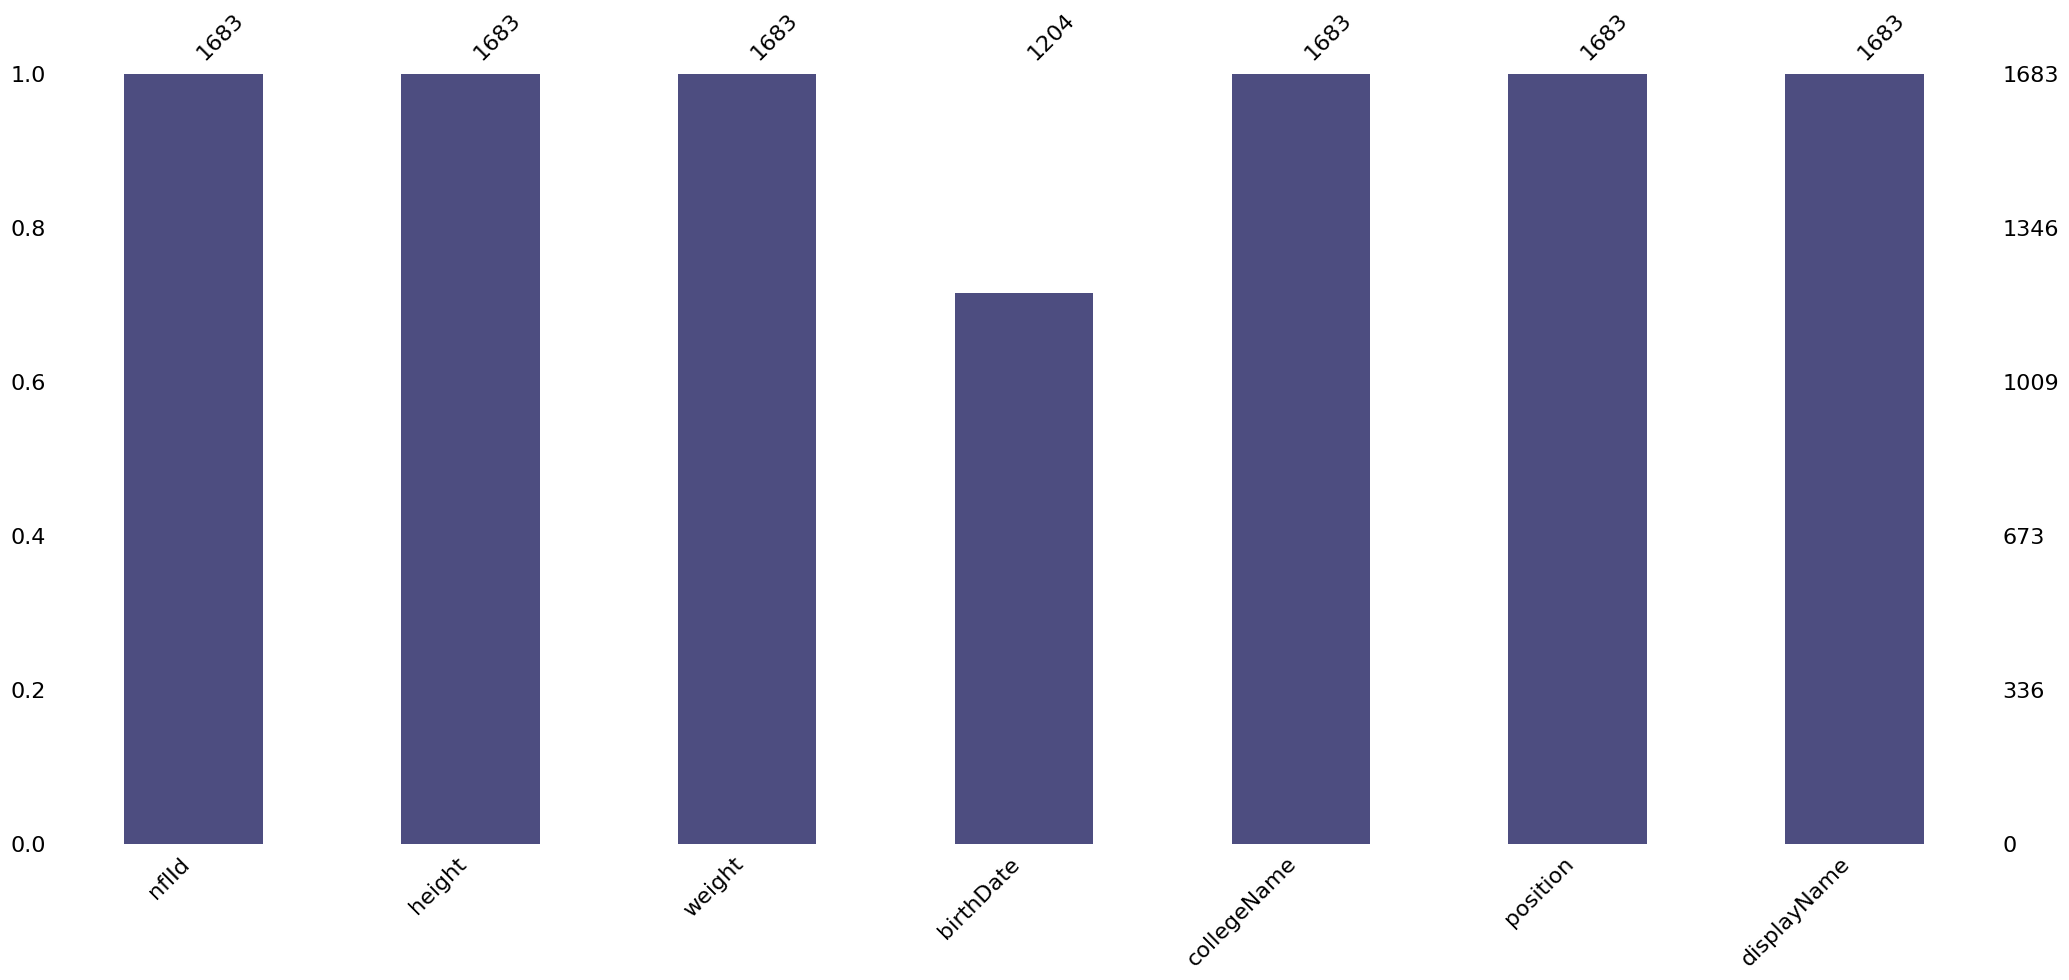

In [10]:
import missingno as msno
msno.bar(players,color=(0.3,0.3,0.5))

<Axes: >

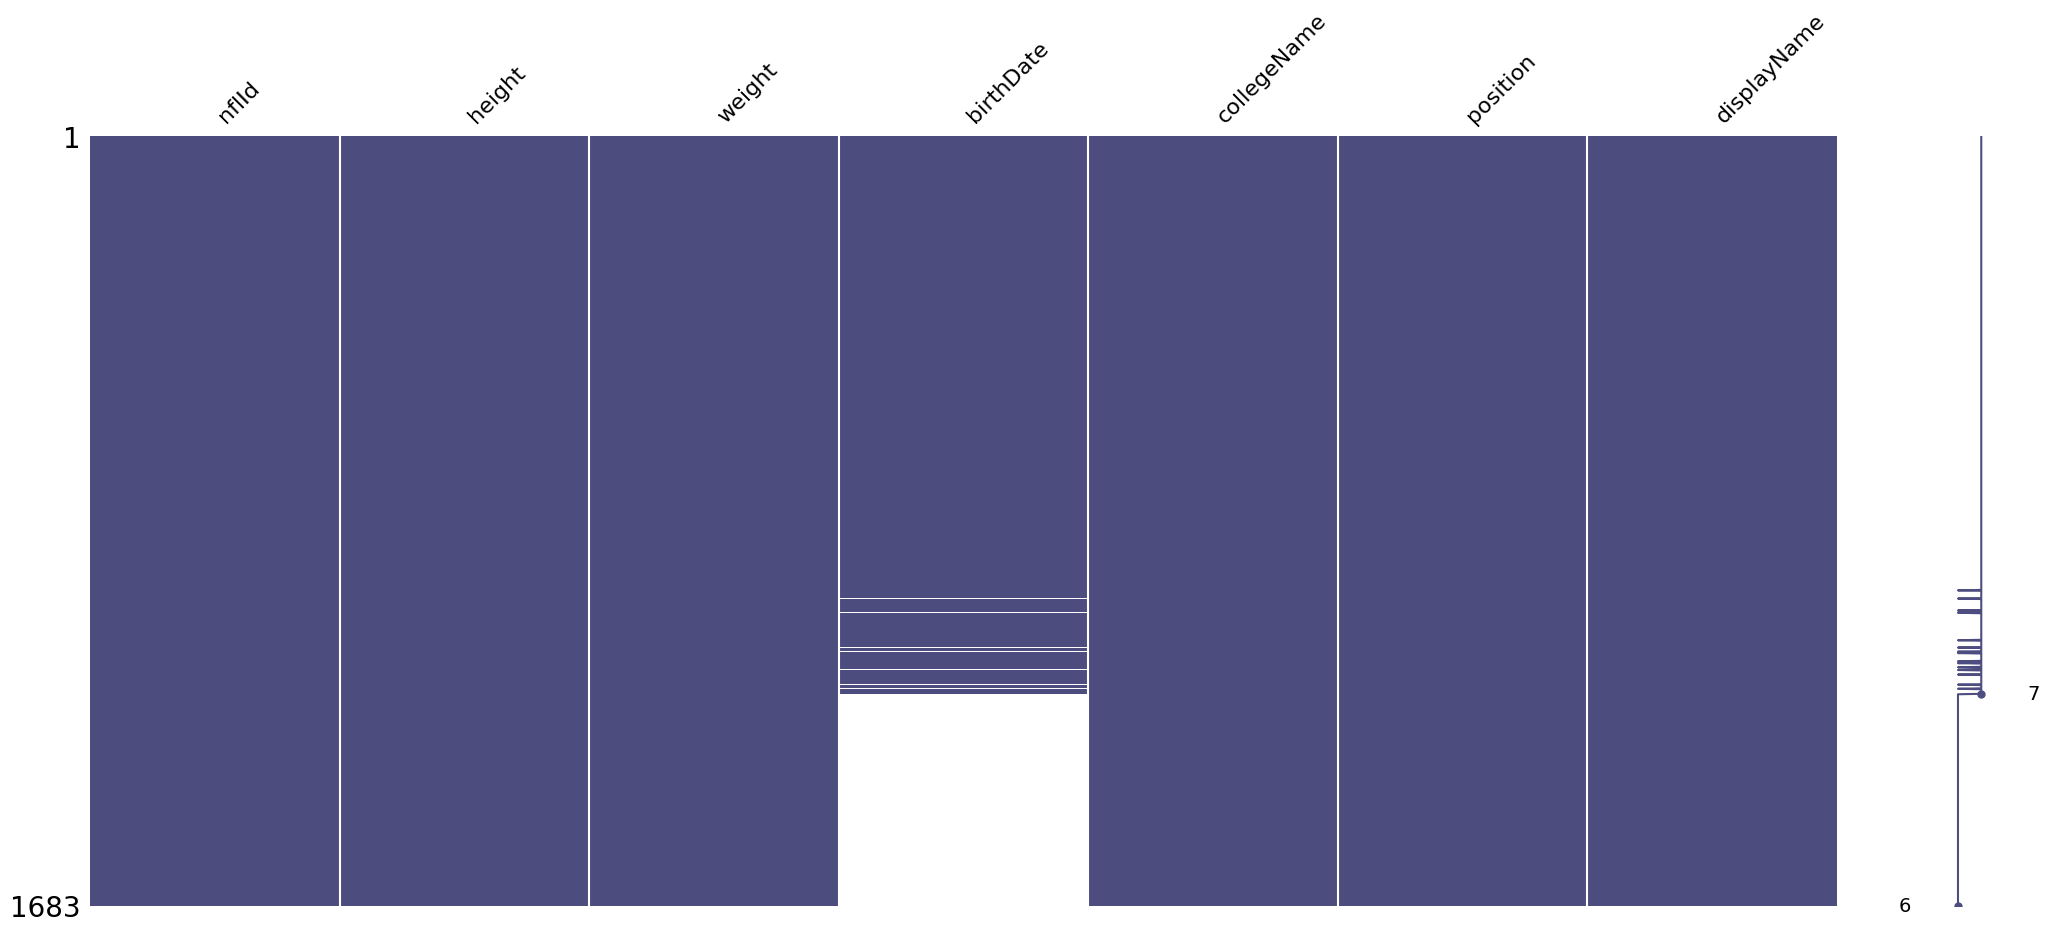

In [11]:
msno.matrix(players, color=(0.3,0.3,0.5))

In [12]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nflId        1683 non-null   int64 
 1   height       1683 non-null   object
 2   weight       1683 non-null   int64 
 3   birthDate    1204 non-null   object
 4   collegeName  1683 non-null   object
 5   position     1683 non-null   object
 6   displayName  1683 non-null   object
dtypes: int64(2), object(5)
memory usage: 92.2+ KB


In [13]:
summarize_dataframe(players).style.background_gradient(cmap='Purples')

,dtypes,missing#,missing%,uniques,first_value,last_value,count,min,max,mean
nflId,int64,0,0.000000,1683,25511,55241,1683,25511.000000,55241.000000,48221.702317
height,object,0,0.000000,16,6-4,6-2,1683,nan,nan,nan
weight,int64,0,0.000000,179,225,280,1683,153.000000,380.000000,245.724302
birthDate,object,47900,28.461081,985,1977-08-03,nan,1204,nan,nan,nan
collegeName,object,0,0.000000,226,Michigan,Coastal Carolina,1683,nan,nan,nan
position,object,0,0.000000,19,QB,DT,1683,nan,nan,nan
displayName,object,0,0.000000,1672,Tom Brady,C.J. Brewer,1683,nan,nan,nan


# Plays Data Inspection


In [14]:
plays = pd.read_csv(f'{BDB_2024_DIR}/plays.csv')
style_df(plays.head(5), "Sample of the plays data")

,gameId,playId,ballCarrierId,ballCarrierDisplayName,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,gameClock,preSnapHomeScore,preSnapVisitorScore,passResult,passLength,penaltyYards,prePenaltyPlayResult,playResult,playNullifiedByPenalty,absoluteYardlineNumber,offenseFormation,defendersInTheBox,passProbability,preSnapHomeTeamWinProbability,preSnapVisitorTeamWinProbability,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPoints,expectedPointsAdded,foulName1,foulName2,foulNFLId1,foulNFLId2
0,2022100908,3537,48723,Parker Hesse,(7:52) (Shotgun) M.Mariota pass short middle to P.Hesse to 50 for 9 yards (K.Neal).,4,1,10,ATL,TB,ATL,41,7:52,21,7,C,6.000000,nan,9,9,N,69,SHOTGUN,7.000000,0.747284,0.976785,0.023215,-0.006110,0.006110,2.360609,0.981955,nan,nan,nan,nan
1,2022091103,3126,52457,Chase Claypool,(7:38) (Shotgun) C.Claypool right end to PIT 37 for 3 yards (C.Awuzie).,4,1,10,PIT,CIN,PIT,34,7:38,14,20,nan,nan,nan,3,3,N,76,SHOTGUN,7.000000,0.416454,0.160485,0.839515,-0.010865,0.010865,1.733344,-0.263424,nan,nan,nan,nan
2,2022091111,1148,42547,Darren Waller,(8:57) D.Carr pass short middle to D.Waller to LV 45 for 15 yards (N.Adderley).,2,2,5,LV,LAC,LV,30,8:57,10,3,C,11.000000,nan,15,15,N,40,I_FORM,6.000000,0.267933,0.756661,0.243339,-0.037409,0.037409,1.312855,1.133666,nan,nan,nan,nan
3,2022100212,2007,46461,Mike Boone,(13:12) M.Boone left tackle to DEN 44 for 7 yards (J.Abram; D.Deablo).,3,2,10,DEN,LV,DEN,37,13:12,19,16,nan,nan,nan,7,7,N,47,SINGLEBACK,6.000000,0.592704,0.620552,0.379448,-0.002451,0.002451,1.641006,-0.043580,nan,nan,nan,nan
4,2022091900,1372,47857,Devin Singletary,(8:33) D.Singletary right guard to TEN 32 for 3 yards (N.Jones; O.Adeniyi). TEN-O.Adeniyi was injured during the play. His return is Questionable. O.Adeniyi walks off.,2,1,10,BUF,TEN,TEN,35,8:33,7,7,nan,nan,nan,3,3,N,75,I_FORM,7.000000,0.470508,0.836290,0.163710,0.001053,-0.001053,3.686428,-0.167903,nan,nan,nan,nan


In [15]:
check_missing_values(plays)


---> column:     gameId	 Percent of NaN value: 0.00%

---> column:     playId	 Percent of NaN value: 0.00%

---> column: ballCarrierId	 Percent of NaN value: 0.00%

---> column: ballCarrierDisplayName	 Percent of NaN value: 0.00%

---> column: playDescription	 Percent of NaN value: 0.00%

---> column:    quarter	 Percent of NaN value: 0.00%

---> column:       down	 Percent of NaN value: 0.00%

---> column:  yardsToGo	 Percent of NaN value: 0.00%

---> column: possessionTeam	 Percent of NaN value: 0.00%

---> column: defensiveTeam	 Percent of NaN value: 0.00%

---> column: yardlineSide	 Percent of NaN value: 1.34%

---> column: yardlineNumber	 Percent of NaN value: 0.00%

---> column:  gameClock	 Percent of NaN value: 0.00%

---> column: preSnapHomeScore	 Percent of NaN value: 0.00%

---> column: preSnapVisitorScore	 Percent of NaN value: 0.00%

---> column: passResult	 Percent of NaN value: 51.11%

---> column: passLength	 Percent of NaN value: 54.88%

---> column: penaltyYards	 Perc

<Axes: >

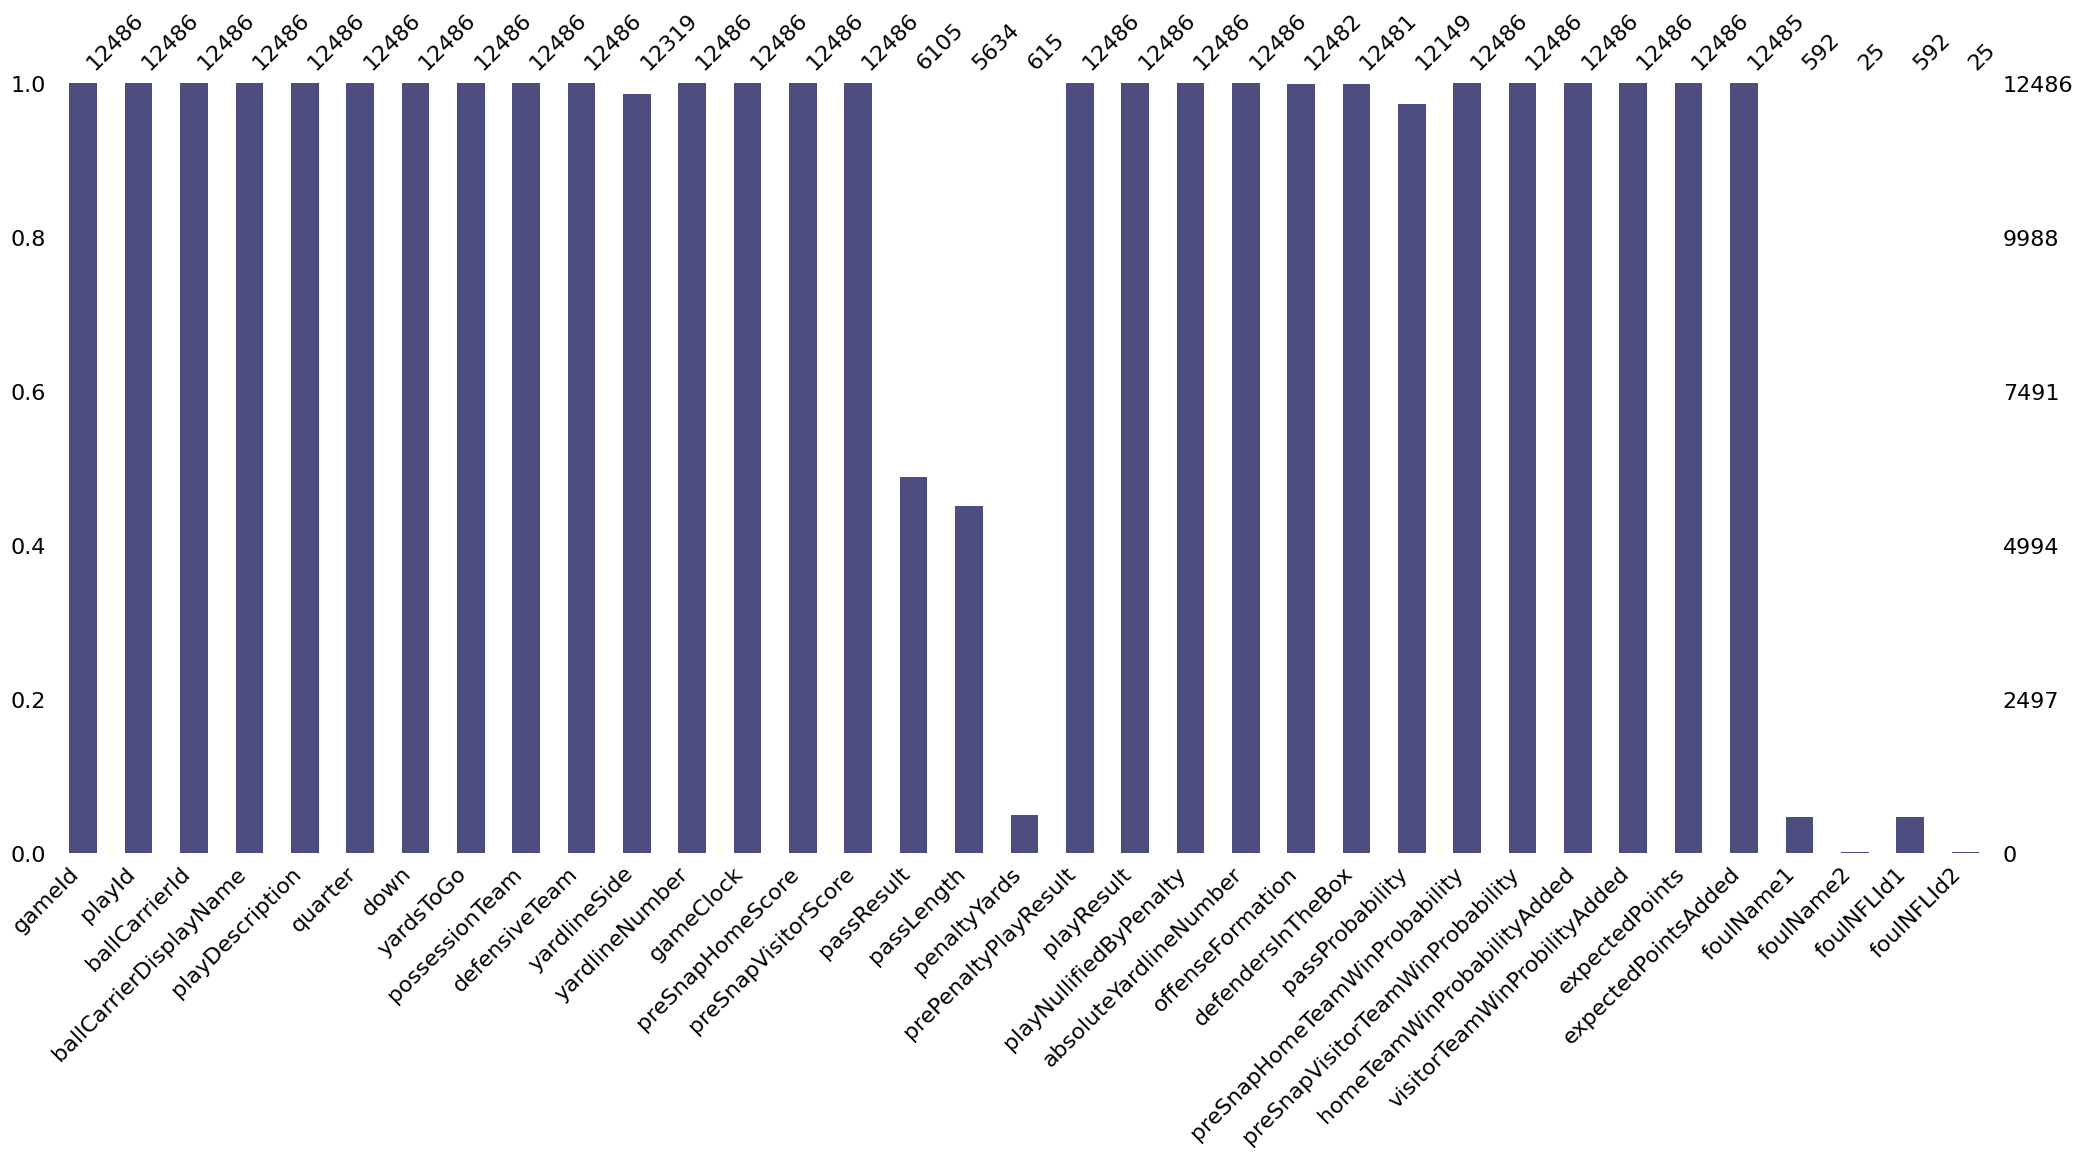

In [16]:
msno.bar(plays, color=(0.3,0.3,0.5))


<Axes: >

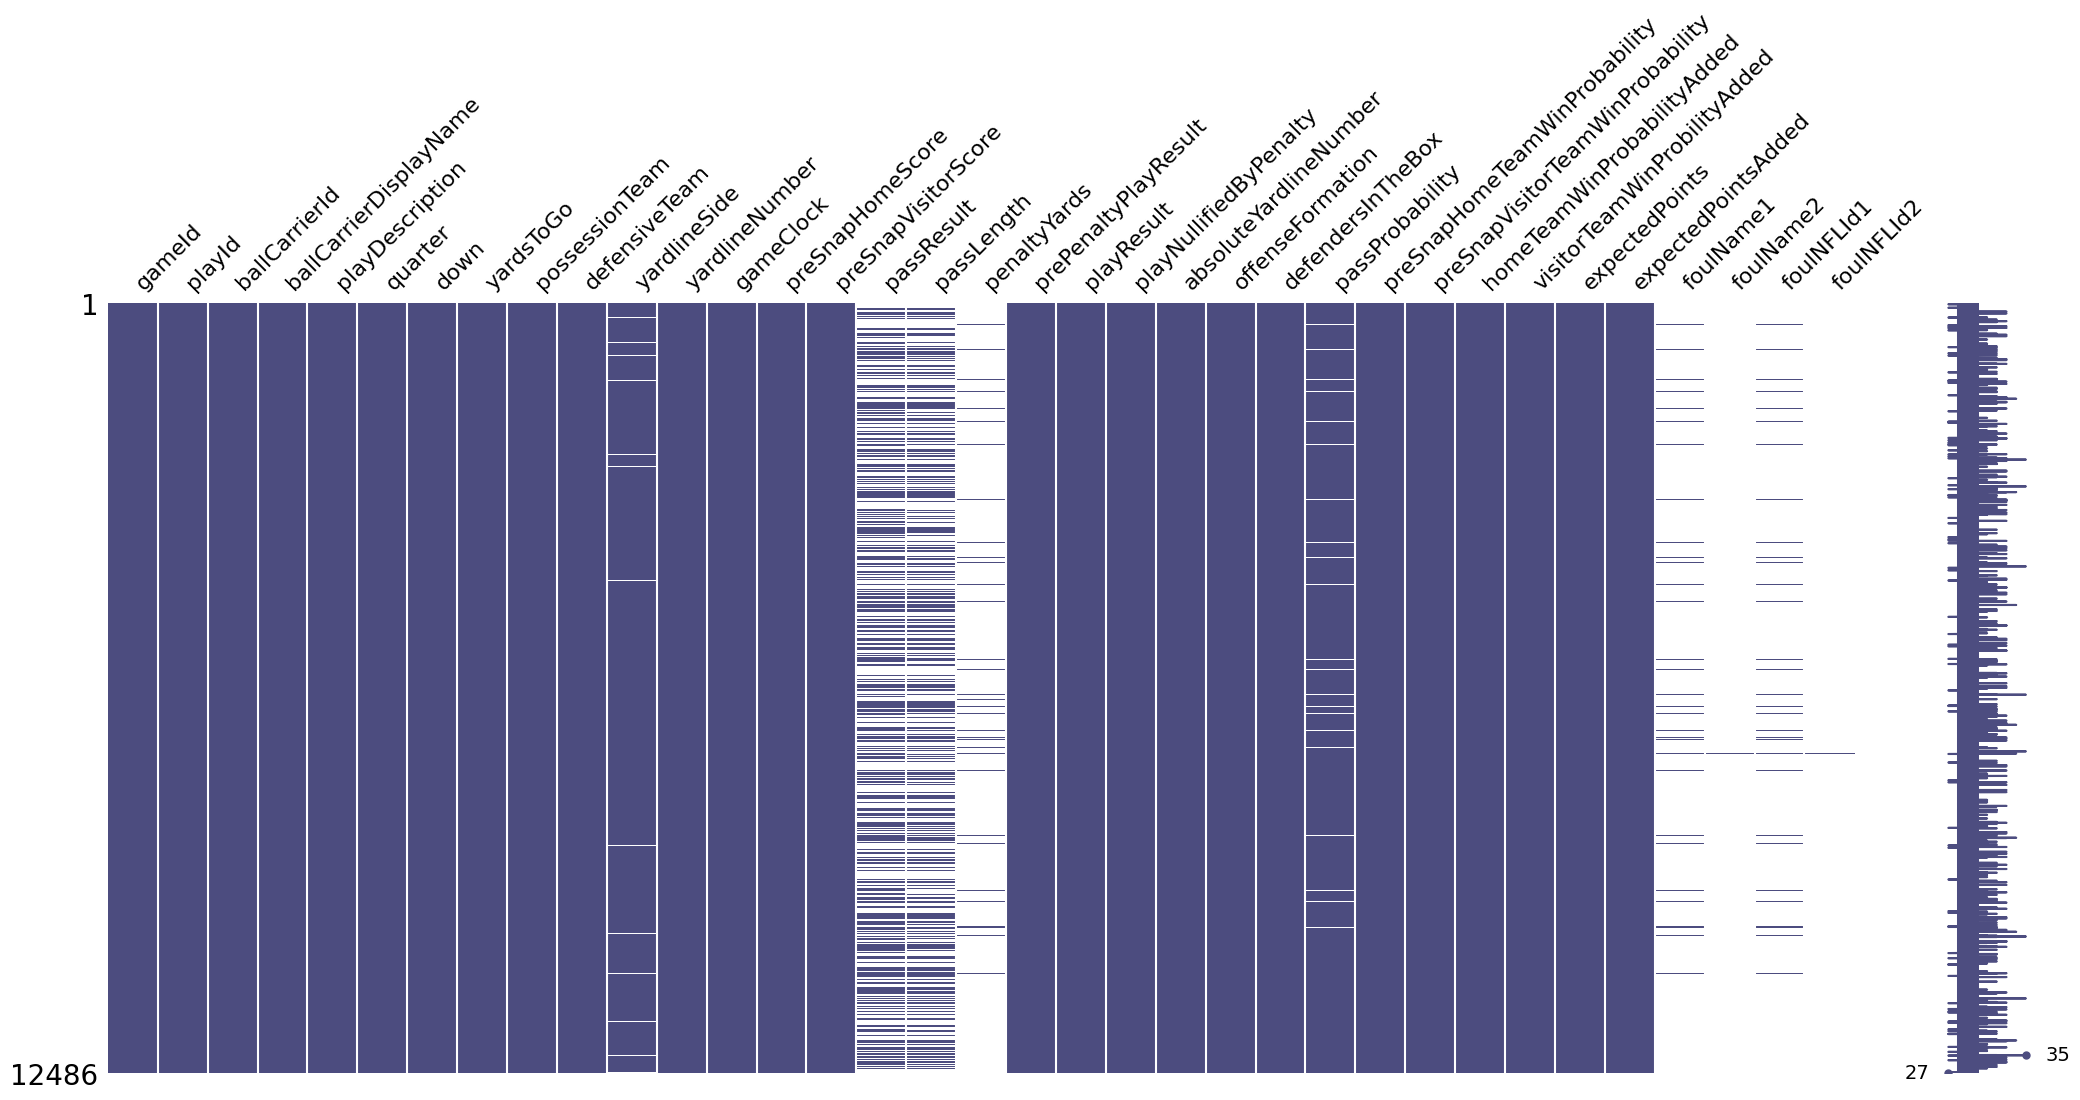

In [17]:
msno.matrix(plays, color=(0.3,0.3,0.5))


In [18]:
plays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12486 entries, 0 to 12485
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gameId                            12486 non-null  int64  
 1   playId                            12486 non-null  int64  
 2   ballCarrierId                     12486 non-null  int64  
 3   ballCarrierDisplayName            12486 non-null  object 
 4   playDescription                   12486 non-null  object 
 5   quarter                           12486 non-null  int64  
 6   down                              12486 non-null  int64  
 7   yardsToGo                         12486 non-null  int64  
 8   possessionTeam                    12486 non-null  object 
 9   defensiveTeam                     12486 non-null  object 
 10  yardlineSide                      12319 non-null  object 
 11  yardlineNumber                    12486 non-null  int64  
 12  game

In [19]:
summarize_dataframe(plays).style.background_gradient(cmap='Purples')

,dtypes,missing#,missing%,uniques,first_value,last_value,count,min,max,mean
gameId,int64,0,0.000000,136,2022100908,2022102308,12486,2022090800.000000,2022110700.000000,2022098953.855598
playId,int64,0,0.000000,3974,3537,905,12486,54.000000,5096.000000,1986.603476
ballCarrierId,int64,0,0.000000,480,48723,54572,12486,25511.000000,55158.000000,48072.271664
ballCarrierDisplayName,object,0,0.000000,480,Parker Hesse,Dameon Pierce,12486,nan,nan,nan
playDescription,object,0,0.000000,12486,(7:52) (Shotgun) M.Mariota pass short middle to P.Hesse to 50 for 9 yards (K.Neal).,(12:51) C.Heck reported in as eligible. D.Pierce up the middle to LV 14 for 3 yards (D.Perryman; D.Deablo).,12486,nan,nan,nan
quarter,int64,0,0.000000,5,4,2,12486,1.000000,5.000000,2.550136
down,int64,0,0.000000,4,1,3,12486,1.000000,4.000000,1.727054
yardsToGo,int64,0,0.000000,32,10,1,12486,1.000000,38.000000,8.469085
possessionTeam,object,0,0.000000,32,ATL,HOU,12486,nan,nan,nan
defensiveTeam,object,0,0.000000,32,TB,LV,12486,nan,nan,nan


In [20]:
# Tackles Data Inspection

In [21]:
tackles = pd.read_csv(f'{BDB_2024_DIR}/tackles.csv')
style_df(tackles.head(5), "Sample of the tackles data")

,gameId,playId,nflId,tackle,assist,forcedFumble,pff_missedTackle
0,2022090800,101,42816,1,0,0,0
1,2022090800,393,46232,1,0,0,0
2,2022090800,486,40166,1,0,0,0
3,2022090800,646,47939,1,0,0,0
4,2022090800,818,40107,1,0,0,0


In [22]:
check_missing_values(tackles)


---> column:     gameId	 Percent of NaN value: 0.00%

---> column:     playId	 Percent of NaN value: 0.00%

---> column:      nflId	 Percent of NaN value: 0.00%

---> column:     tackle	 Percent of NaN value: 0.00%

---> column:     assist	 Percent of NaN value: 0.00%

---> column: forcedFumble	 Percent of NaN value: 0.00%

---> column: pff_missedTackle	 Percent of NaN value: 0.00%


In [23]:
tackles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17426 entries, 0 to 17425
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gameId            17426 non-null  int64
 1   playId            17426 non-null  int64
 2   nflId             17426 non-null  int64
 3   tackle            17426 non-null  int64
 4   assist            17426 non-null  int64
 5   forcedFumble      17426 non-null  int64
 6   pff_missedTackle  17426 non-null  int64
dtypes: int64(7)
memory usage: 953.1 KB


In [24]:
summarize_dataframe(tackles).style.background_gradient(cmap='Purples')

,dtypes,missing#,missing%,uniques,first_value,last_value,count,min,max,mean
gameId,int64,0,0.000000,136,2022090800,2022091901,17426,2022090800.000000,2022110700.000000,2022098971.441123
playId,int64,0,0.000000,3943,101,3845,17426,54.000000,5096.000000,1982.974578
nflId,int64,0,0.000000,800,42816,46199,17426,33131.000000,55241.000000,47602.719442
tackle,int64,0,0.000000,2,1,0,17426,0.000000,1.000000,0.569207
assist,int64,0,0.000000,2,0,0,17426,0.000000,1.000000,0.315276
forcedFumble,int64,0,0.000000,2,0,0,17426,0.000000,1.000000,0.005681
pff_missedTackle,int64,0,0.000000,2,0,1,17426,0.000000,1.000000,0.119936


# Tracking Data Inspection

In [25]:
tr_week_1 = pd.read_csv(f'{BDB_2024_DIR}/tracking_week_1.csv')
style_df(tr_week_1.head(5), "Sample of the tracking data for week 1")

,gameId,playId,nflId,displayName,frameId,time,jerseyNumber,club,playDirection,x,y,s,a,dis,o,dir,event
0,2022090800,56,35472.000000,Rodger Saffold,1,2022-09-08 20:24:05.200000,76.000000,BUF,left,88.370000,27.270000,1.620000,1.150000,0.160000,231.740000,147.900000,nan
1,2022090800,56,35472.000000,Rodger Saffold,2,2022-09-08 20:24:05.299999,76.000000,BUF,left,88.470000,27.130000,1.670000,0.610000,0.170000,230.980000,148.530000,pass_arrived
2,2022090800,56,35472.000000,Rodger Saffold,3,2022-09-08 20:24:05.400000,76.000000,BUF,left,88.560000,27.010000,1.570000,0.490000,0.150000,230.980000,147.050000,nan
3,2022090800,56,35472.000000,Rodger Saffold,4,2022-09-08 20:24:05.500000,76.000000,BUF,left,88.640000,26.900000,1.440000,0.890000,0.140000,232.380000,145.420000,nan
4,2022090800,56,35472.000000,Rodger Saffold,5,2022-09-08 20:24:05.599999,76.000000,BUF,left,88.720000,26.800000,1.290000,1.240000,0.130000,233.360000,141.950000,nan


In [26]:
check_missing_values(tr_week_1)


---> column:     gameId	 Percent of NaN value: 0.00%

---> column:     playId	 Percent of NaN value: 0.00%

---> column:      nflId	 Percent of NaN value: 4.35%

---> column: displayName	 Percent of NaN value: 0.00%

---> column:    frameId	 Percent of NaN value: 0.00%

---> column:       time	 Percent of NaN value: 0.00%

---> column: jerseyNumber	 Percent of NaN value: 4.35%

---> column:       club	 Percent of NaN value: 0.00%

---> column: playDirection	 Percent of NaN value: 0.00%

---> column:          x	 Percent of NaN value: 0.00%

---> column:          y	 Percent of NaN value: 0.00%

---> column:          s	 Percent of NaN value: 0.00%

---> column:          a	 Percent of NaN value: 0.00%

---> column:        dis	 Percent of NaN value: 0.00%

---> column:          o	 Percent of NaN value: 4.34%

---> column:        dir	 Percent of NaN value: 4.34%

---> column:      event	 Percent of NaN value: 90.74%


<Axes: >

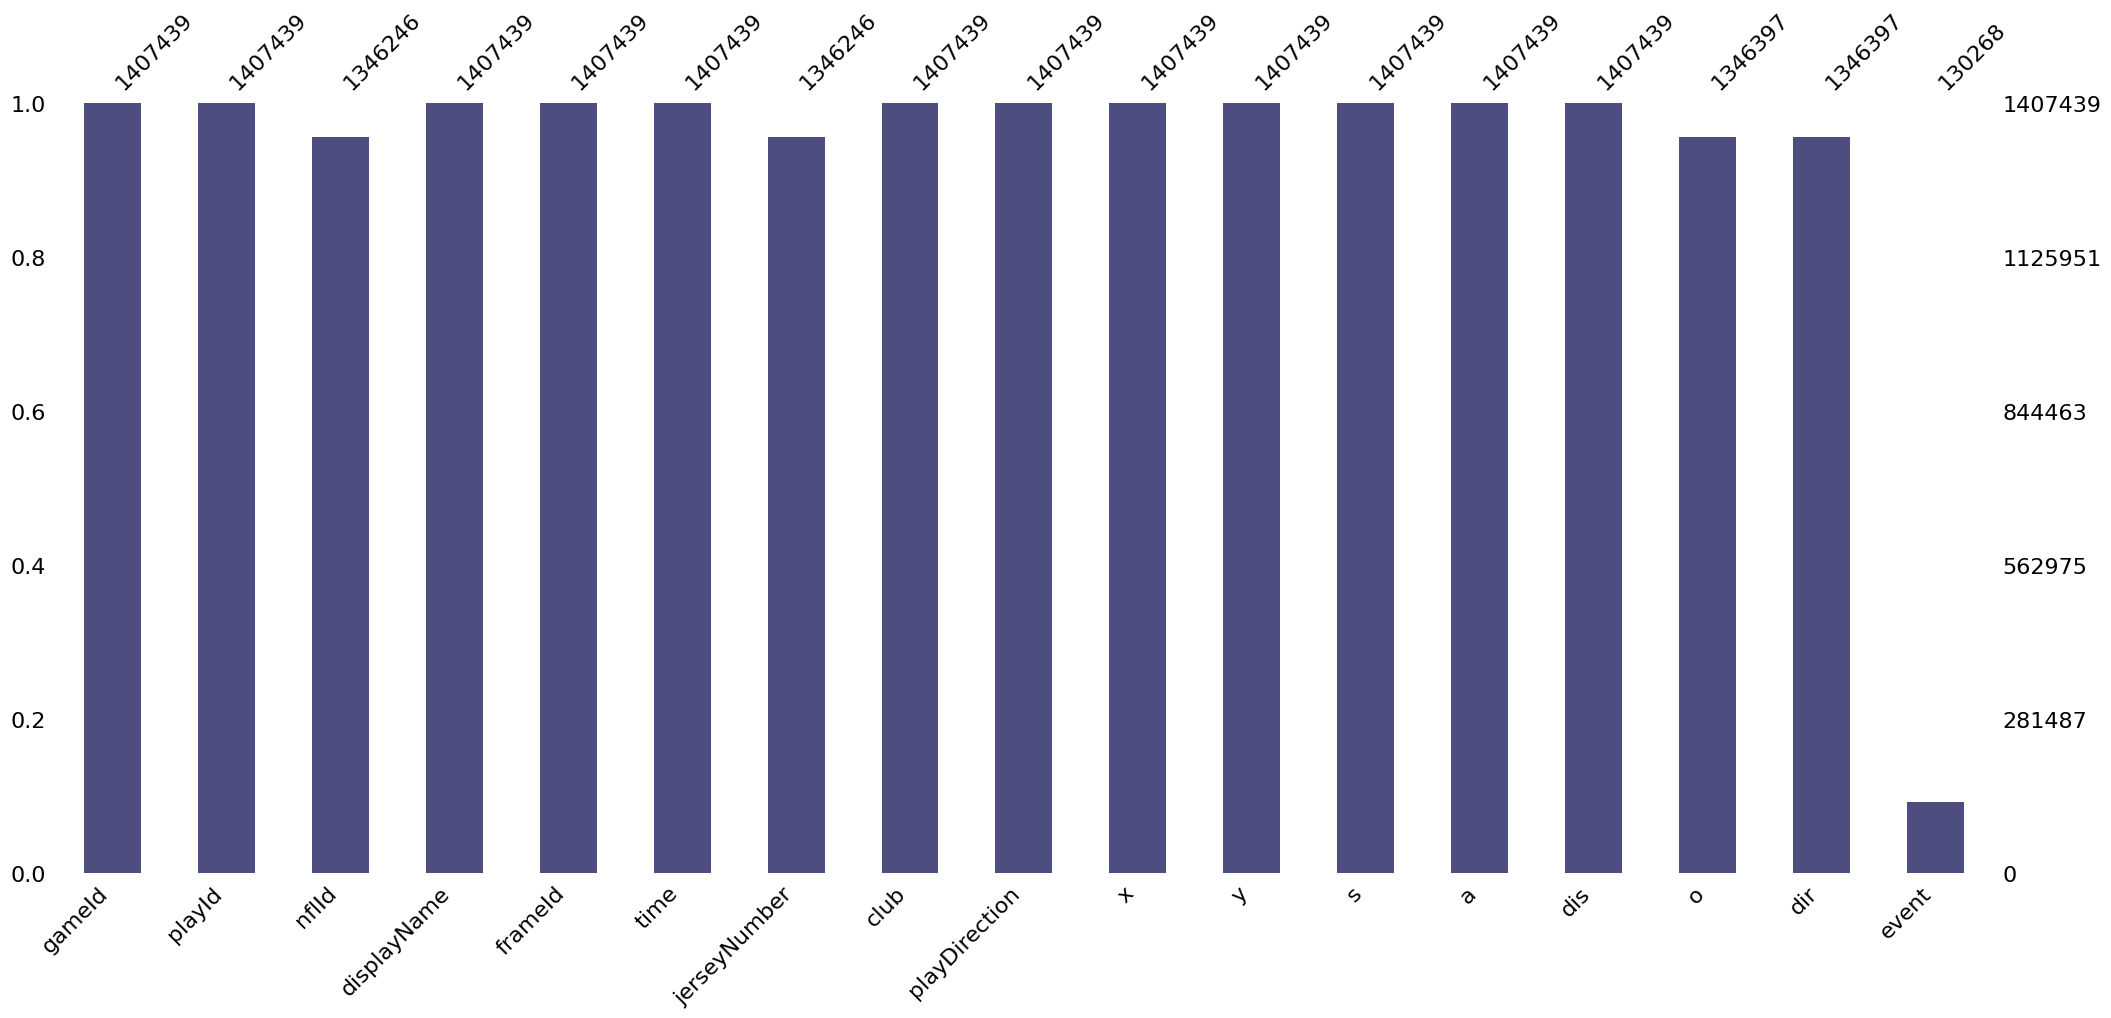

In [27]:
msno.bar(tr_week_1, color=(0.3,0.3,0.5))

<Axes: >

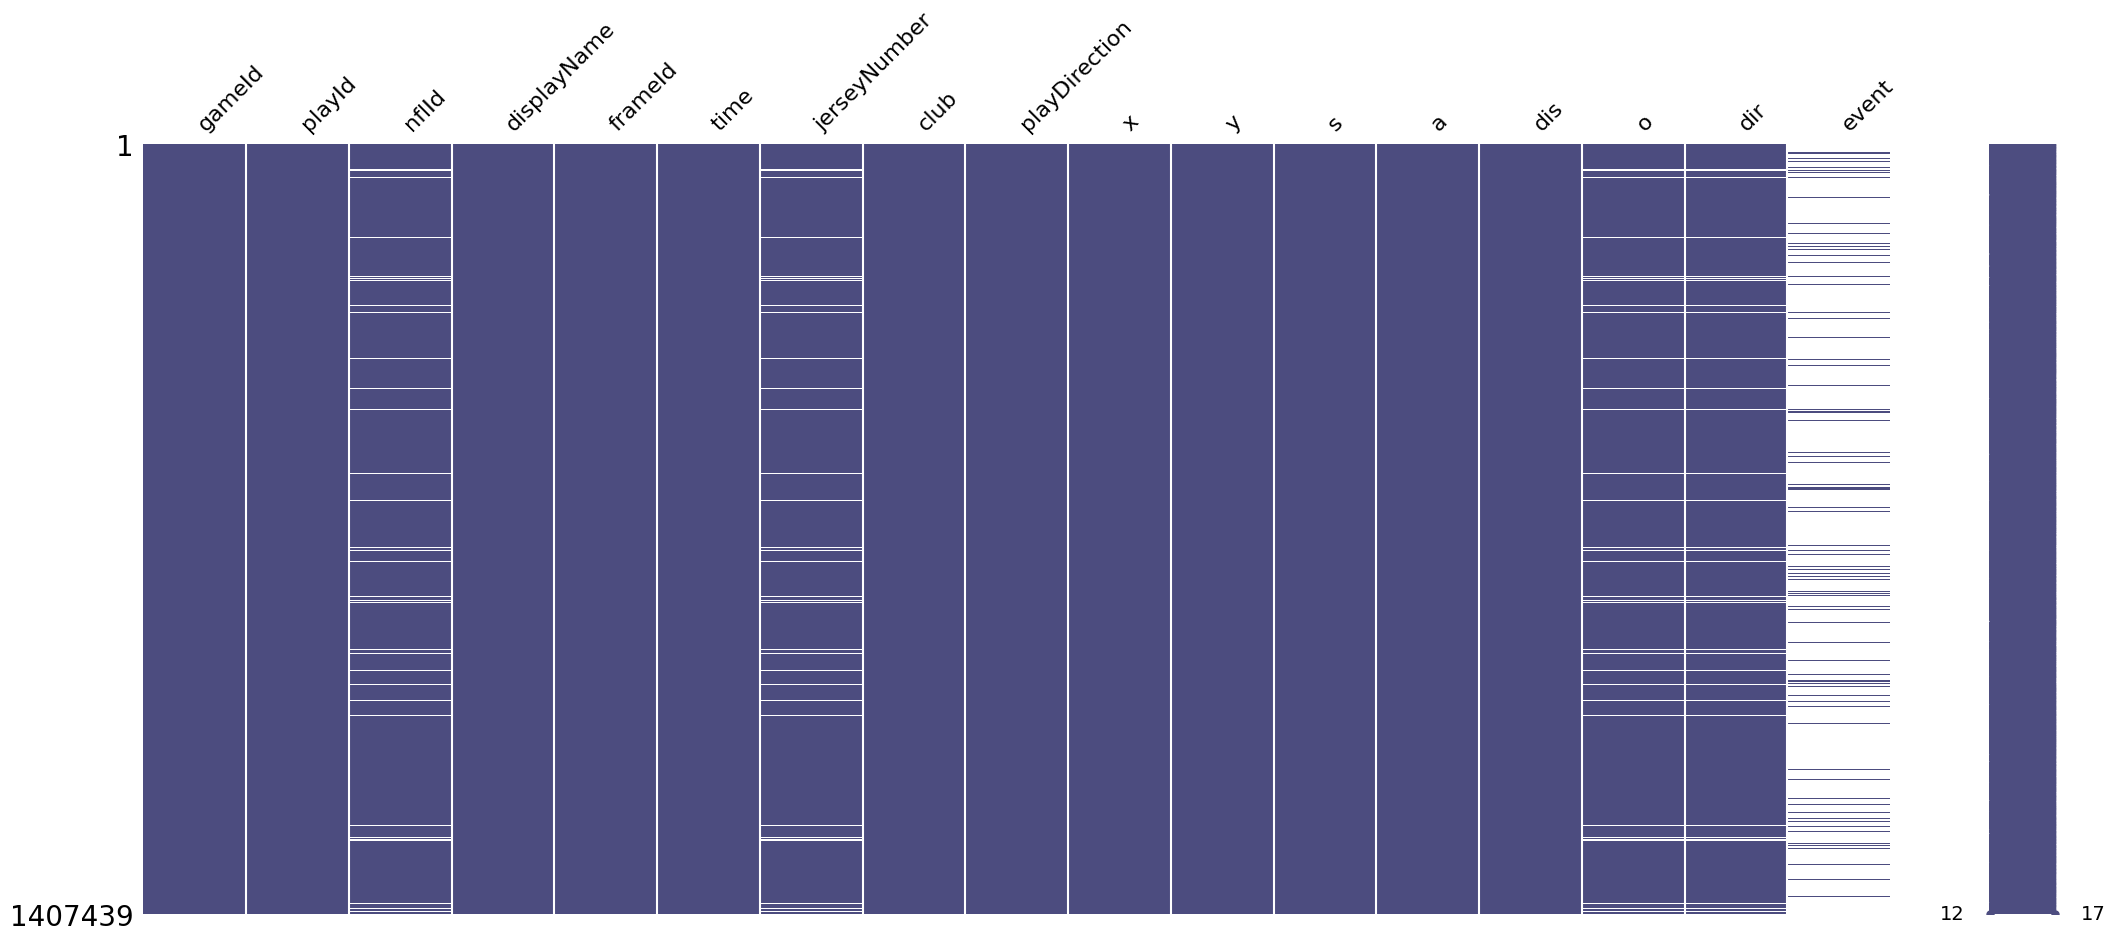

In [28]:
msno.matrix(tr_week_1, color=(0.3,0.3,0.5))

In [29]:
tr_week_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407439 entries, 0 to 1407438
Data columns (total 17 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   gameId         1407439 non-null  int64  
 1   playId         1407439 non-null  int64  
 2   nflId          1346246 non-null  float64
 3   displayName    1407439 non-null  object 
 4   frameId        1407439 non-null  int64  
 5   time           1407439 non-null  object 
 6   jerseyNumber   1346246 non-null  float64
 7   club           1407439 non-null  object 
 8   playDirection  1407439 non-null  object 
 9   x              1407439 non-null  float64
 10  y              1407439 non-null  float64
 11  s              1407439 non-null  float64
 12  a              1407439 non-null  float64
 13  dis            1407439 non-null  float64
 14  o              1346397 non-null  float64
 15  dir            1346397 non-null  float64
 16  event          130268 non-null   object 
dtypes: float

In [30]:
summarize_dataframe(tr_week_1).style.background_gradient(cmap='Purples')

,dtypes,missing#,missing%,uniques,first_value,last_value,count,min,max,mean
gameId,int64,0,0.000000,16,2022090800,2022091200,1407439,2022090800.000000,2022091200.000000,2022091094.552367
playId,int64,0,0.000000,1247,56,3826,1407439,55.000000,5096.000000,2030.071299
nflId,float64,6119300,4.347826,1171,35472.000000,nan,1346246,25511.000000,55173.000000,47241.911904
displayName,object,0,0.000000,1166,Rodger Saffold,football,1407439,nan,nan,nan
frameId,int64,0,0.000000,114,1,53,1407439,1.000000,114.000000,25.121795
time,object,0,0.000000,55516,2022-09-08 20:24:05.200000,2022-09-12 23:05:58.200000,1407439,nan,nan,nan
jerseyNumber,float64,6119300,4.347826,99,76.000000,nan,1346246,1.000000,99.000000,48.478239
club,object,0,0.000000,33,BUF,football,1407439,nan,nan,nan
playDirection,object,0,0.000000,2,left,left,1407439,nan,nan,nan
x,float64,0,0.000000,21453,88.370000,55.570000,1407439,-1.270000,120.160000,61.720514


In [31]:
del tr_week_1
# Returns the number of
# objects it has collected
# and deallocated
collected = gc.collect()
 
# Prints Garbage collector
# as 0 object
print("Garbage collector: collected",
          "%d objects." % collected)# Importing gc module

Garbage collector: collected 80 objects.


# Chapter 4: Insights from Games Data

In [32]:
check = games['gameDate'].value_counts().reset_index()

check.columns = [
    'date', 
    'games'
]

check = check.sort_values('date')

fig = px.bar(
    check, 
    y='date', 
    x="games", 
    orientation='h', 
    color='date',
    title='Number of games by dates', 
    height=900, 
    width=800,
    color_discrete_sequence=px.colors.qualitative.Prism,
)
fig.show()

In [33]:
check = games['week'].value_counts().reset_index()

check.columns = [
    'week', 
    'games'
]

check = check.sort_values('week')

fig = px.bar(
    check, 
    y='week', 
    x="games", 
    orientation='h', 
    color='games',
    text='games',
    title='Number of games by weeks', 
    height=900, 
    width=800,
    #color_discrete_sequence=px.colors.qualitative.Prism,
    color_continuous_scale=px.colors.sequential.Purples
)
fig.show()

In [34]:
dfg_home = games['homeTeamAbbr'].value_counts().reset_index()
dfg_home.columns = ['team', 'number_of_home_games']

dfg_away = games['visitorTeamAbbr'].value_counts().reset_index()
dfg_away.columns = ['team', 'number_of_away_games']

outer_merged = pd.merge(
     dfg_home, dfg_away, how="outer", on=["team"]
)

fig = go.Figure()

fig.add_bar(x=outer_merged['team'],y=outer_merged['number_of_home_games'], 
            hovertext="Number of home games", name="number_of_home_games", 
            marker_color=px.colors.qualitative.Prism[0])    # "orange"
fig.add_bar(x=outer_merged['team'],y=outer_merged['number_of_away_games'], 
            hovertext="Number of visiting games", name="number_of_away_games", 
            marker_color=px.colors.qualitative.Prism[1]) # "green"

# Update visual layout
fig.update_layout(
    showlegend=True,
    width=800,
    height=400,
    autosize=False,
    margin=dict(t=30, b=0, l=5, r=5),
    template="plotly_white",
    yaxis_title="Number of Games",
    title=dict(text='Home vs. Visiting Games by Teams', font=dict(size=20), yref='paper')
)

# update font size at the axes
fig.update_coloraxes(colorbar_tickfont_size=10)
# Update font in the titles: Apparently subplot titles are annotations (Subplot font size is hardcoded to 16pt · Issue #985)
fig.update_annotations(font_size=12)
# Reduce opacity
fig.update_traces(opacity=0.75)

fig.show()

In [35]:
style_df(outer_merged,"Home vs. Visiting Games by Teams")

,team,number_of_home_games,number_of_away_games
0,NO,6,3
1,LA,5,3
2,WAS,5,4
3,JAX,5,4
4,CLE,5,3
5,ATL,5,4
6,DAL,5,3
7,ARI,5,4
8,TB,5,4
9,NYJ,5,4


In [36]:
agg_dict_1 = {
    "min_home_score": pd.NamedAgg(column='homeFinalScore', aggfunc='min'),
    "max_home_score": pd.NamedAgg(column='homeFinalScore', aggfunc='max'),
    "avg_home_score": pd.NamedAgg(column='homeFinalScore', aggfunc=np.mean),

}

agg_data = games.groupby("homeTeamAbbr").agg(**agg_dict_1).reset_index()

In [37]:
fig = go.Figure()

fig.add_bar(x=agg_data['homeTeamAbbr'],y=agg_data['min_home_score'], 
            hovertext="Minimal score in home games", name="min_home_score", 
            marker_color=px.colors.qualitative.Prism[0])    # "orange"
fig.add_bar(x=agg_data['homeTeamAbbr'],y=agg_data['avg_home_score'], 
            hovertext="Average score in home games", name="avg_home_score", 
            marker_color=px.colors.qualitative.Prism[1]) # "green"
fig.add_bar(x=agg_data['homeTeamAbbr'],y=agg_data['max_home_score'], 
            hovertext="Maximal score in home games", name="max_home_score", 
            marker_color=px.colors.qualitative.Prism[2]) # "green"

# Update visual layout
fig.update_layout(
    showlegend=True,
    width=800,
    height=400,
    autosize=False,
    margin=dict(t=30, b=0, l=5, r=5),
    template="plotly_white",
    yaxis_title="Scores",
    title=dict(text='Scores in Home Games by Teams', font=dict(size=20), yref='paper')
)

# update font size at the axes
fig.update_coloraxes(colorbar_tickfont_size=10)
# Update font in the titles: Apparently subplot titles are annotations (Subplot font size is hardcoded to 16pt · Issue #985)
fig.update_annotations(font_size=12)
# Reduce opacity
fig.update_traces(opacity=0.75)

fig.show()

## Final Scores in Away Games by Teams

In [38]:
agg_dict_2 = {
    "min_away_score": pd.NamedAgg(column='visitorFinalScore', aggfunc='min'),
    "max_away_score": pd.NamedAgg(column='visitorFinalScore', aggfunc='max'),
    "avg_away_score": pd.NamedAgg(column='visitorFinalScore', aggfunc=np.mean)
}

agg_data = games.groupby("visitorTeamAbbr").agg(**agg_dict_2).reset_index()

In [39]:
fig = go.Figure()

fig.add_bar(x=agg_data['visitorTeamAbbr'],y=agg_data['min_away_score'], 
            hovertext="Minimal score in away games", name="min_away_score", 
            marker_color=px.colors.qualitative.Prism[0])    # "orange"
fig.add_bar(x=agg_data['visitorTeamAbbr'],y=agg_data['avg_away_score'], 
            hovertext="Average score in away games", name="avg_away_score", 
            marker_color=px.colors.qualitative.Prism[1]) # "green"
fig.add_bar(x=agg_data['visitorTeamAbbr'],y=agg_data['max_away_score'], 
            hovertext="Maximal score in away games", name="max_away_score", 
            marker_color=px.colors.qualitative.Prism[2]) # "green"

# Update visual layout
fig.update_layout(
    showlegend=True,
    width=800,
    height=400,
    autosize=False,
    margin=dict(t=30, b=0, l=5, r=5),
    template="plotly_white",
    yaxis_title="Scores",
    title=dict(text='Scores in Away Games by Teams', font=dict(size=20), yref='paper')
)

# update font size at the axes
fig.update_coloraxes(colorbar_tickfont_size=10)
# Update font in the titles: Apparently subplot titles are annotations (Subplot font size is hardcoded to 16pt · Issue #985)
fig.update_annotations(font_size=12)
# Reduce opacity
fig.update_traces(opacity=0.75)

fig.show()

# Chapter 5: Insights from Player Data

In [40]:
style_df(players.head(),"Sample of Player Data")

,nflId,height,weight,birthDate,collegeName,position,displayName
0,25511,6-4,225,1977-08-03,Michigan,QB,Tom Brady
1,29550,6-4,328,1982-01-22,Arkansas,T,Jason Peters
2,29851,6-2,225,1983-12-02,California,QB,Aaron Rodgers
3,30842,6-6,267,1984-05-19,UCLA,TE,Marcedes Lewis
4,33084,6-4,217,1985-05-17,Boston College,QB,Matt Ryan


## Player Data Transformation and Feature Engineering

In [41]:
# cast height to the metric system - namely, in m

new_players = players['height'].str.split('-',expand=True)
new_players.columns=['Foot','Inch']
new_players['Foot'] = new_players['Foot'].astype(int)
new_players['Inch'] = new_players['Inch'].astype(int)
new_players['Foot'] = new_players['Foot'] * 30.48
new_players['Inch'] = new_players['Inch'] * 2.54
new_players['height_cm'] = new_players['Foot'] + new_players['Inch']


players['height'] = new_players['height_cm'] / 100
# cast the weights to metric units - namely, to kg
players['weight'] = players['weight'] * 0.45



formats = ["%Y-%m-%d", "%m/%d/%Y"]
parsed_dt = pd.to_datetime(players.birthDate, format=formats[0], errors='coerce')
for format in formats[1:]:
    parsed_dt = parsed_dt.fillna(pd.to_datetime(players.birthDate, format=format, errors='coerce'))

players['birthDate'] = parsed_dt

def group_position(position):
    if position in ['QB', 'T', 'TE', 'WR', 'C', 'G', 'RB', 'FB']:
        return 'offensive'
    return 'defensive'


players['position_group'] = players['position'].apply(group_position)

players.height = players.height.round(2)
players.weight = players.weight.round(2)

# formula inherited from https://www.calculatorsoup.com/calculators/health/bmi-calculator.php
players['mass_index'] = players['weight']/( players['height'] * players['height'] )

players.mass_index = players.mass_index.round(2)

def group_index(index):
    bmi_lower_fence = 21.64
    bmi_q1 = 27.18
    bmi_median = 29.87
    bmi_q3 = 34.53
    
    if index < bmi_q1:
        return 'S'
    elif bmi_q1 <= index < bmi_median:
        return 'M'
    elif bmi_median <= index < bmi_q3:
        return 'L'
    else:
        return 'XL'

players['bmi_group'] = players['mass_index'].apply(group_index)

today = dt.datetime.today()

players['age'] = players['birthDate'].apply(
               lambda x: today.year - x.year - 
               ((today.month, today.day) < (x.month, x.day)) 
               )

players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   nflId           1683 non-null   int64         
 1   height          1683 non-null   float64       
 2   weight          1683 non-null   float64       
 3   birthDate       1204 non-null   datetime64[ns]
 4   collegeName     1683 non-null   object        
 5   position        1683 non-null   object        
 6   displayName     1683 non-null   object        
 7   position_group  1683 non-null   object        
 8   mass_index      1683 non-null   float64       
 9   bmi_group       1683 non-null   object        
 10  age             1204 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 144.8+ KB


In [42]:
del new_players
# Returns the number of
# objects it has collected
# and deallocated
collected = gc.collect()
 
# Prints Garbage collector
# as 0 object
print("Garbage collector: collected",
          "%d objects." % collected)# Importing gc module

Garbage collector: collected 2602 objects.


In [43]:
style_df(players.head(),"Sample of the Player data (after transformation and FE)")


,nflId,height,weight,birthDate,collegeName,position,displayName,position_group,mass_index,bmi_group,age
0,25511,1.930000,101.250000,1977-08-03 00:00:00,Michigan,QB,Tom Brady,offensive,27.180000,M,47.000000
1,29550,1.930000,147.600000,1982-01-22 00:00:00,Arkansas,T,Jason Peters,offensive,39.630000,XL,43.000000
2,29851,1.880000,101.250000,1983-12-02 00:00:00,California,QB,Aaron Rodgers,offensive,28.650000,M,41.000000
3,30842,1.980000,120.150000,1984-05-19 00:00:00,UCLA,TE,Marcedes Lewis,offensive,30.650000,L,41.000000
4,33084,1.930000,97.650000,1985-05-17 00:00:00,Boston College,QB,Matt Ryan,offensive,26.220000,S,40.000000


In [44]:
# Players By Age
fig = px.histogram(players, x="age", marginal="rug",
                   title='Distribution of Players by Age',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [45]:
fig = px.box(players, x="age",
                   title='Summary Statistics on Players by Age',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [46]:
fig = px.box(players, x="position_group", y="age",
                   title='Summary Statistics on Players by Age and Offensive/Defensive Position',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [47]:
avg_age  = players.groupby(['collegeName'])['age'].mean()

frame = {
    'collegeName': avg_age.index,
    'avg_player_age': avg_age
}


dfg_agg = pd.DataFrame(frame)

dfg_agg = dfg_agg.sort_values('avg_player_age', ascending=True)

In [48]:
fig = px.bar(
    dfg_agg, 
    y='collegeName', 
    x="avg_player_age", 
    orientation='h', 
    title='Average age of players in the college teams', 
    height=900, 
    width=800,
    color_discrete_sequence=px.colors.qualitative.Prism,
)
fig.show()

In [49]:
dfg_agg.sort_values(['avg_player_age'], 
                   ascending=False)[
                        [
                          'collegeName',
                          'avg_player_age',
                        ]
][:10].style.background_gradient(cmap='seismic')

,collegeName,avg_player_age
collegeName,,
Troy,Troy,37.000000
"California, Pa.","California, Pa.",35.000000
"Regina, Can.","Regina, Can.",35.000000
Presbyterian,Presbyterian,35.000000
Minn. State-Mankato,Minn. State-Mankato,34.000000
Arkansas State,Arkansas State,33.500000
Wisconsin-Whitewater,Wisconsin-Whitewater,33.000000
Bloomsburg,Bloomsburg,33.000000
Canisius,Canisius,33.000000


In [50]:
dfg_agg.sort_values(['avg_player_age'], 
                   ascending=True)[
                        [
                          'collegeName',
                          'avg_player_age',
                        ]
][:10].style.background_gradient(cmap='seismic')

,collegeName,avg_player_age
collegeName,,
Berry,Berry,26.000000
"St. John's, Minn.","St. John's, Minn.",26.000000
Stetson University,Stetson University,27.000000
Army,Army,27.000000
Assumption,Assumption,27.000000
Missouri S&T,Missouri S&T,27.000000
Brown,Brown,27.000000
Norfolk State,Norfolk State,27.000000
Bowling Green,Bowling Green,27.000000


In [51]:
fig = px.histogram(players, x="mass_index", marginal="rug",
                   title='Distribution of Players by Body Mass Index (BMI)',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [52]:
fig = px.box(players, x="mass_index",
                   title='Summary Statistics on Players by Body Mass Index (BMI)',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [53]:
fig = px.box(players, x="position_group", y="mass_index",
                   title='Summary Statistics on Players by BMI and Offensive/Defensive Position',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [54]:
avg_bmi  = players.groupby(['collegeName'])['mass_index'].mean()

frame = {
    'collegeName': avg_bmi.index,
    'avg_player_bmi': avg_bmi
}


dfg_agg = pd.DataFrame(frame)

dfg_agg = dfg_agg.sort_values('avg_player_bmi', ascending=True)

In [55]:
fig = px.bar(
    dfg_agg, 
    y='collegeName', 
    x="avg_player_bmi", 
    orientation='h', 
    title='Average BMI of players by the college graduated', 
    height=900, 
    width=800,
    color_discrete_sequence=px.colors.qualitative.Prism,
)
fig.show()

In [56]:
agg_data = players[['nflId', 'displayName', 'mass_index']]
agg_data.sort_values(['mass_index'], 
                   ascending=False)[
                        [
                            'nflId',
                            'displayName',
                            'mass_index',
                        ]
][:20].style.background_gradient(cmap='seismic')

,nflId,displayName,mass_index
1651,54948,Marquan McCall,47.240000
388,43694,Michael Pierce,45.690000
928,48198,Bryan Mone,45.620000
155,41336,Justin Ellis,44.560000
1129,52592,Bravvion Roy,43.780000
1128,52590,Michael Onwenu,43.630000
838,47867,Khalen Saunders,43.540000
1171,52743,Benito Jones,43.260000
366,43455,D.J. Reader,43.250000
1327,53551,Tyler Shelvin,43.130000


In [57]:
agg_data.sort_values(['mass_index'], 
                   ascending=True)[
                        [
                            'nflId',
                            'displayName',
                            'mass_index',
                        ]
][:20].style.background_gradient(cmap='seismic')

,nflId,displayName,mass_index
1518,54546,Cordale Flott,21.640000
1231,53439,DeVonta Smith,21.690000
686,46277,Cedrick Wilson,22.020000
1489,54515,Tyquan Thornton,22.440000
1219,53117,Kavontae Turpin,22.480000
1275,53486,Tutu Atwell,22.480000
992,52272,Dee Alford,22.840000
805,47829,Greedy Williams,23.430000
1354,53586,Ihmir Smith-Marsette,23.540000
1165,52697,James Pierre,23.550000


In [58]:
agg_data = players[["position_group", "bmi_group"]].groupby(["position_group", "bmi_group"]).size().reset_index(name="count")
# define figure element
fig = px.sunburst(
    agg_data,
    values='count',
    path=["position_group", "bmi_group"],
    title="BMI Group-to-Player Position Group Association",
    color="position_group",
    height=600,
    color_discrete_sequence=px.colors.qualitative.Prism,
    #color_continuous_scale=px.colors.sequential.Viridis
)
# display the figure
fig.show()

# Chapter 6: Insights from Tackles Data

In [59]:
style_df(tackles.head(),"Sample of the Tackle data")

,gameId,playId,nflId,tackle,assist,forcedFumble,pff_missedTackle
0,2022090800,101,42816,1,0,0,0
1,2022090800,393,46232,1,0,0,0
2,2022090800,486,40166,1,0,0,0
3,2022090800,646,47939,1,0,0,0
4,2022090800,818,40107,1,0,0,0


In [60]:
## Tackles Per Game
tackle_games = tackles.groupby(['gameId'])['tackle'].agg('sum')

frame = {'game_id': tackle_games.index,
         'tackles': tackle_games}
 
# Creating DataFrame by passing Dictionary
agg_data = pd.DataFrame(frame).reset_index()
agg_data = agg_data.drop(columns=['game_id'], axis=1)

fig = px.histogram(agg_data, x="tackles", marginal="rug",
                   title='Distribution of Tackles per Game',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [61]:
fig = px.box(agg_data, x="tackles",
                   title='Summary Statistics on Tackles per Game',
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()

In [62]:
agg_data.sort_values(['tackles'], 
                   ascending=False)[
                        [
                          'gameId',
                          'tackles',
                        ]
][:10].style.background_gradient(cmap='seismic')

,gameId,tackles
114,2022103005,94
6,2022091105,91
37,2022092504,91
93,2022101700,90
106,2022102311,89
67,2022100902,88
5,2022091104,86
104,2022102309,86
110,2022103001,86
76,2022100911,85


In [63]:
agg_data.sort_values(['tackles'], 
                   ascending=True)[
                        [
                          'gameId',
                          'tackles',
                        ]
][:10].style.background_gradient(cmap='seismic')

,gameId,tackles
25,2022091808,51
55,2022100206,53
21,2022091804,57
130,2022110606,58
75,2022100910,58
101,2022102306,59
119,2022103010,60
13,2022091112,60
2,2022091101,60
23,2022091806,61


... chapter 6 cont...

# Chapter 7: Evaluating Player Tackle Performance (part 1)

📝 Tackle Efficiency: we calculate tackle_efficiency for each player by dividing the total number of tackles by the sum of tackles and missed tackles; this metric will give us an idea of how efficient a player is when they attempt to tackle.
the supportive metric of total_tackles is defined as a sum of tackles and assists committed by a player

In [64]:
agg_dict_1 = {
    "tackles": pd.NamedAgg(column='tackle', aggfunc='sum'),
    "assists": pd.NamedAgg(column='assist', aggfunc='sum'),
    "forced_fumbles": pd.NamedAgg(column='forcedFumble', aggfunc='sum'),
    "missed_tackles": pd.NamedAgg(column='pff_missedTackle', aggfunc='sum'),
}

player_tackle_df = tackles.groupby("nflId").agg(**agg_dict_1).reset_index()

# calculate player tackle efficiency
# inspired by https://www.kaggle.com/code/sasakitetsuya/1st-step-data-summary-and-understanding
player_tackle_df['total_tackles'] = player_tackle_df['tackles'] + player_tackle_df['assists']
player_tackle_df['tackle_efficiency'] = player_tackle_df['total_tackles'] / (player_tackle_df['total_tackles'] + player_tackle_df['missed_tackles'])


player_tackles = pd.merge(
    players,
    player_tackle_df,
    how="inner",
    on=['nflId']
)

style_df(player_tackles.head(), "Sample of the Player data with tackle stats")

,nflId,height,weight,birthDate,collegeName,position,displayName,position_group,mass_index,bmi_group,age,tackles,assists,forced_fumbles,missed_tackles,total_tackles,tackle_efficiency
0,33131,2.030000,135.000000,1986-09-01 00:00:00,Miami,DE,Calais Campbell,defensive,32.760000,L,38.000000,8,10,0,4,18,0.818182
1,35449,1.900000,136.800000,1987-05-12 00:00:00,California,NT,Tyson Alualu,defensive,37.890000,XL,38.000000,4,4,0,1,8,0.888889
2,35452,1.880000,119.250000,1988-04-03 00:00:00,Michigan,DE,Brandon Graham,defensive,33.740000,L,37.000000,6,6,0,1,12,0.923077
3,35454,1.960000,123.750000,1989-01-01 00:00:00,South Florida,DE,Jason Pierre-Paul,defensive,32.210000,L,36.000000,3,3,0,1,6,0.857143
4,35459,1.780000,83.250000,1988-04-10 00:00:00,Alabama,SS,Kareem Jackson,defensive,26.280000,S,37.000000,28,23,0,9,51,0.850000


In [65]:
del player_tackle_df
# Returns the number of
# objects it has collected
# and deallocated
collected = gc.collect()
 
# Prints Garbage collector
# as 0 object
print("Garbage collector: collected",
          "%d objects." % collected)# Importing gc module

Garbage collector: collected 5614 objects.
